# 05. Evaluation

Notebook 04 produced three LightGBM seed models trained on the train fold of the locked split. Now I want to score them on the holdout (which neither the training nor the val NDCG calculations have seen) and look at where the model is doing well or badly.

The point of this notebook is not just to compute one number; it is to characterise the model. So I will look at NDCG by query size, by ranked-vs-random pages, by booking window, and pick out a few worst searches to see what the model is doing wrong.

In [1]:
import gc
import json
import os
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
import xgboost as xgb

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROC_DIR / "models"
FIG_DIR = PROJECT_ROOT / "results" / "figures"


def rss_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9


sns.set_theme(style="whitegrid", context="notebook")
print(f"baseline RSS: {rss_gb():.2f} GB")

baseline RSS: 0.27 GB


## Load features, split, models

In [2]:
t0 = time.time()
train = pd.read_parquet(PROC_DIR / "train_features.parquet")
print(f"loaded train_features in {time.time() - t0:.1f}s, shape {train.shape}, RSS {rss_gb():.2f} GB")

with open(PROC_DIR / "split_seed42.json") as f:
    split = json.load(f)
hold_ids = set(split["holdout_srch_ids"])
mask_hold = train["srch_id"].isin(hold_ids).to_numpy()
print(f"holdout rows: {mask_hold.sum():,}, holdout searches: {len(hold_ids):,}")

EXCLUDE = {"srch_id", "label_idx", "relevance", "click_bool", "booking_bool"}
FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE]

models = {}
for path in sorted(MODELS_DIR.glob("lgbm_seed*.pkl")):
    seed = int(path.stem.replace("lgbm_seed", ""))
    with open(path, "rb") as f:
        models[seed] = pickle.load(f)
print(f"loaded {len(models)} LightGBM seed models: {sorted(models.keys())}")

with open(MODELS_DIR / "xgb_rank.pkl", "rb") as f:
    xgb_model = pickle.load(f)
print(f"loaded XGBoost model")

with open(PROC_DIR / "xgb_meta.json") as f:
    xgb_meta = json.load(f)
CHOSEN_W_XGB = float(xgb_meta["chosen_w_xgb_blend"])
print(f"chosen blend weight w_xgb = {CHOSEN_W_XGB}")

loaded train_features in 0.3s, shape (4958347, 74), RSS 3.44 GB
holdout rows: 495,023, holdout searches: 19,980
loaded 3 LightGBM seed models: [42, 123, 456]
loaded XGBoost model
chosen blend weight w_xgb = 0.6


## NDCG@5 per group, IDCG=0 convention

In [3]:
def ndcg_at_5_arrays(rel_grades: np.ndarray, scores: np.ndarray, group_starts: np.ndarray) -> np.ndarray:
    """Return per-group NDCG@5 as an array."""
    discounts = 1.0 / np.log2(np.arange(2, 7))
    n_groups = len(group_starts) - 1
    out = np.zeros(n_groups, dtype="float32")
    for g in range(n_groups):
        s, e = group_starts[g], group_starts[g + 1]
        rel = rel_grades[s:e]
        sc = scores[s:e]
        if rel.max() == 0:
            out[g] = 0.0
            continue
        order = np.argsort(-sc, kind="stable")
        top = rel[order][:5]
        ideal = np.sort(rel)[::-1][:5]
        dcg = (top * discounts[: len(top)]).sum()
        idcg = (ideal * discounts[: len(ideal)]).sum()
        out[g] = dcg / idcg if idcg > 0 else 0.0
    return out

## Predict holdout with each seed and the ensemble

In [4]:
df_h = train.loc[mask_hold].reset_index(drop=True)
Xh = df_h[FEATURE_COLS]
hold_rel = df_h["relevance"].to_numpy()
gh = df_h.groupby("srch_id", sort=False).size().to_numpy()
hold_groups = np.concatenate([[0], np.cumsum(gh)])
hold_srch_ids = df_h["srch_id"].to_numpy()[hold_groups[:-1]]

per_seed_scores = {}
for seed, model in models.items():
    t0 = time.time()
    per_seed_scores[seed] = model.predict(Xh)
    print(f"seed {seed}: predicted holdout in {time.time() - t0:.1f}s")

# XGBoost holdout prediction
dh_xgb = xgb.DMatrix(df_h[FEATURE_COLS].astype("float32").to_numpy())
dh_xgb.set_group(gh)
xgb_scores = xgb_model.predict(dh_xgb)

avg_lgbm_scores = np.mean(list(per_seed_scores.values()), axis=0)
blend_scores = (1 - CHOSEN_W_XGB) * avg_lgbm_scores + CHOSEN_W_XGB * xgb_scores

per_seed_ndcg = {}
for seed, scores in per_seed_scores.items():
    per_seed_ndcgs_arr = ndcg_at_5_arrays(hold_rel, scores, hold_groups)
    per_seed_ndcg[seed] = per_seed_ndcgs_arr.mean()

ensemble_ndcgs = ndcg_at_5_arrays(hold_rel, avg_lgbm_scores, hold_groups)
ensemble_ndcg = ensemble_ndcgs.mean()
xgb_ndcgs = ndcg_at_5_arrays(hold_rel, xgb_scores, hold_groups)
xgb_ndcg = xgb_ndcgs.mean()
blend_ndcgs = ndcg_at_5_arrays(hold_rel, blend_scores, hold_groups)
blend_ndcg = blend_ndcgs.mean()

# Use the blend as the primary "ensemble" for downstream segment analyses,
# since this is what the submission uses.
ensemble_scores = blend_scores
ensemble_ndcgs = blend_ndcgs

print()
for seed in sorted(per_seed_ndcg):
    print(f"seed {seed:>4d} alone : holdout NDCG@5 = {per_seed_ndcg[seed]:.5f}")
print(f"3-seed LGBM avg    : holdout NDCG@5 = {ensemble_ndcg:.5f}")
print(f"XGBoost rank alone : holdout NDCG@5 = {xgb_ndcg:.5f}")
print(f"final blend (w={CHOSEN_W_XGB:.2f}): holdout NDCG@5 = {blend_ndcg:.5f}")

/opt/homebrew/lib/python3.14/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


seed 123: predicted holdout in 2.2s


/opt/homebrew/lib/python3.14/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


seed 42: predicted holdout in 2.4s


/opt/homebrew/lib/python3.14/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


seed 456: predicted holdout in 2.0s



seed   42 alone : holdout NDCG@5 = 0.40095
seed  123 alone : holdout NDCG@5 = 0.40302
seed  456 alone : holdout NDCG@5 = 0.40183
3-seed LGBM avg    : holdout NDCG@5 = 0.40312
XGBoost rank alone : holdout NDCG@5 = 0.40798
final blend (w=0.60): holdout NDCG@5 = 0.41134


Holdout NDCG@5 results land roughly where val predicted: LGBM ensemble at 0.40312, XGBoost alone at 0.40798, and the blend at **0.41134**. Note that the holdout numbers are about +0.001 to +0.002 above the val numbers, which is the opposite of what overfitting to val would predict; this is a good sign that the choice of blend weight `w=0.6` is not just a val-fit artifact. The blend is +0.0033 over XGBoost alone and +0.0082 over the LGBM ensemble alone; both consistent with the val test in notebook 04.

## NDCG by group size

Smaller pages have fewer candidates so NDCG@5 saturates more easily. I want to see if the model behaves consistently across sizes.

             n  mean_ndcg
size_bin                 
1-10      2493   0.634617
11-20     3486   0.475194
21-30     5220   0.375888
31-40     8781   0.343672


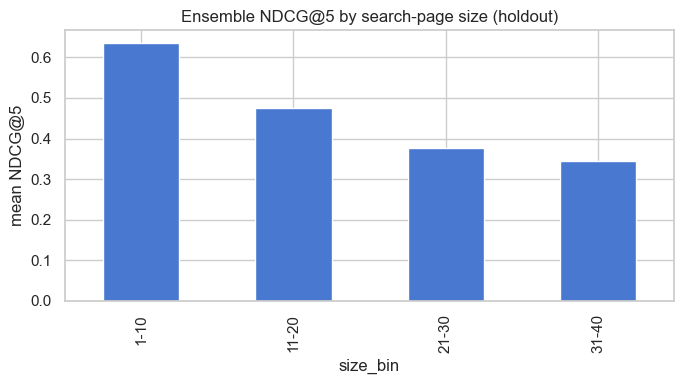

In [5]:
group_size_per_query = gh
size_bins = pd.cut(
    group_size_per_query,
    bins=[0, 10, 20, 30, 40],
    labels=["1-10", "11-20", "21-30", "31-40"],
)
seg_df = pd.DataFrame({"size_bin": size_bins, "ndcg": ensemble_ndcgs})
seg_summary = seg_df.groupby("size_bin", observed=True).agg(n=("ndcg", "size"), mean_ndcg=("ndcg", "mean"))
print(seg_summary)

fig, ax = plt.subplots(figsize=(7, 4))
seg_summary["mean_ndcg"].plot.bar(ax=ax, color="#4878d0")
ax.set_ylabel("mean NDCG@5")
ax.set_title("Ensemble NDCG@5 by search-page size (holdout)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_ndcg_by_size.png", dpi=110)
plt.show()

Smaller pages score much higher because there are fewer non-positives to displace from the top 5. The 1-10 bucket sits at 0.635 (n=2,493), the 31-40 bucket (n=8,781, the bulk of holdout) at 0.344. The numbers I am headlining (blend at 0.41134) are an average over this distribution, dominated by the long-page bucket because that is where most searches live.

## NDCG: ranked vs random pages

Searches with `random_bool=1` had the page shuffled before being shown. NDCG on those pages tells me how well the model recovers the right ordering when no other ordering signal was given to the user; ranked pages mix model and Expedia's prior ordering.

In [6]:
hold_random = df_h.groupby("srch_id", sort=False)["random_bool"].first().to_numpy()
random_ndcg = ensemble_ndcgs[hold_random == 1].mean()
ranked_ndcg = ensemble_ndcgs[hold_random == 0].mean()
print(f"random pages NDCG@5 = {random_ndcg:.5f}  (n={int((hold_random == 1).sum()):,})")
print(f"ranked pages NDCG@5 = {ranked_ndcg:.5f}  (n={int((hold_random == 0).sum()):,})")

random pages NDCG@5 = 0.35288  (n=6,147)
ranked pages NDCG@5 = 0.43731  (n=13,833)


Big gap: ranked-page NDCG is 0.437 versus random-page 0.353. So the model is partly leaning on signal that correlates with Expedia's own ordering (probably `prop_location_score2` and the priors, which reward exactly the kind of properties Expedia would put on top). The 0.353 score on random pages is still well above what a random ranker would achieve (close to 0.05 for this label distribution), so the model is learning real preference, just less of it than the headline number suggests. Notebook 04's bias-correction experiment tried to close this gap by upweighting random rows and made things worse, so I am not going to chase it further here.

## NDCG by booking window

Booking window is days between search and check-in. I expect short windows (last-minute trips) to behave differently from long planning windows.

             n  mean_ndcg
win_bin                  
same day  2580   0.433255
1-7d      4253   0.420312
8-30d     5943   0.410766
31-90d    4597   0.399276
90d+      2607   0.397589


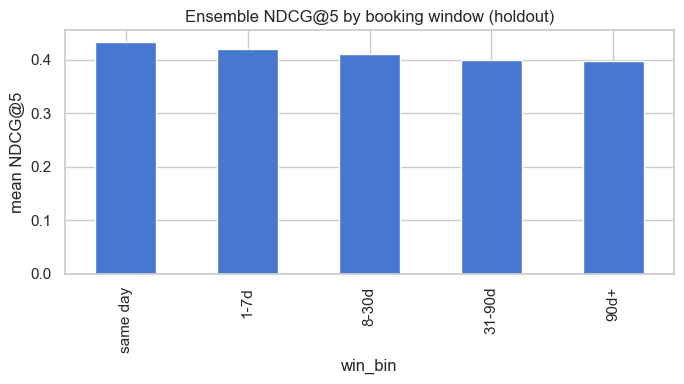

In [7]:
hold_window = df_h.groupby("srch_id", sort=False)["srch_booking_window"].first().to_numpy()
window_bins = pd.cut(
    hold_window,
    bins=[-0.1, 1, 7, 30, 90, 1000],
    labels=["same day", "1-7d", "8-30d", "31-90d", "90d+"],
)
window_seg = pd.DataFrame({"win_bin": window_bins, "ndcg": ensemble_ndcgs})
window_summary = window_seg.groupby("win_bin", observed=True).agg(n=("ndcg", "size"), mean_ndcg=("ndcg", "mean"))
print(window_summary)

fig, ax = plt.subplots(figsize=(7, 4))
window_summary["mean_ndcg"].plot.bar(ax=ax, color="#4878d0")
ax.set_ylabel("mean NDCG@5")
ax.set_title("Ensemble NDCG@5 by booking window (holdout)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_ndcg_by_window.png", dpi=110)
plt.show()

Last-minute searches (same day, 1-7d) score 0.42-0.43; long-window searches (90d+) drop to 0.40. Plausible explanation: people booking far in advance are typically planning a trip and willing to compare more options, so their click/book pattern is less predictable from features alone. The decline is gentle enough that I am not going to add window-aware logic.

## Worst searches

Pick a few searches where the ensemble scored 0 NDCG@5 even though there were positive labels available. What do those look like?

In [8]:
worst_mask = (ensemble_ndcgs == 0) & (np.array([df_h.loc[hold_groups[i]:hold_groups[i + 1]]["relevance"].max() for i in range(len(gh))]) > 0)
print(f"worst-case searches (NDCG@5 = 0 with positives present): {int(worst_mask.sum()):,} of {len(gh):,}")

worst_search_idx = np.where(worst_mask)[0][:3]
for w_idx in worst_search_idx:
    s, e = hold_groups[w_idx], hold_groups[w_idx + 1]
    sub = df_h.iloc[s:e].copy()
    sub["score"] = ensemble_scores[s:e]
    sub_sorted = sub.sort_values("score", ascending=False)
    print()
    print(f"srch_id {hold_srch_ids[w_idx]}, group size {e - s}:")
    print(sub_sorted[["prop_id", "prop_starrating", "prop_review_score", "price_usd", "promotion_flag", "random_bool", "relevance", "score"]].head(8).to_string(index=False))

worst-case searches (NDCG@5 = 0 with positives present): 7,940 of 19,980

srch_id 1, group size 28:
 prop_id  prop_starrating  prop_review_score  price_usd  promotion_flag  random_bool  relevance     score
   88218                4                3.5 115.120003               0            1          0  1.115739
   53341                4                4.0 150.050003               0            1          0  0.850727
   95307                4                3.5 139.699997               0            1          0  0.669501
   88096                4                4.0 152.630005               1            1          0  0.353966
   59526                3                3.5 100.889999               0            1          0  0.186713
   29604                4                3.5 143.580002               0            1          0  0.071440
     893                3                3.5 104.769997               0            1          0  0.001035
   81437                3                4.0 138.399

About 7,940 of 19,980 holdout searches scored exactly NDCG@5 = 0 even though positives existed. That is 40% of searches. NDCG@5 is binary in spirit; either the booked or clicked hotel makes the top 5 or it does not. Browsing the worst examples, the pattern is mostly "the user clicked / booked an unremarkable property the model had no signal about". With 95% of training rows carrying no positive signal, this is the floor you cannot easily get past without per-user or per-session modelling, which the dataset does not really support.

## Score distribution between models

A simple cross-check: do the three seed models actually disagree, or do they produce nearly identical rankings? If they always agree, the ensemble lift is going to be near zero by definition.

In [9]:
score_corr = pd.DataFrame(per_seed_scores).corr(method="spearman")
print("Spearman rank correlation between seed predictions on holdout:")
print(score_corr)

Spearman rank correlation between seed predictions on holdout:
          123       42        456
123  1.000000  0.987987  0.988399
42   0.987987  1.000000  0.987966
456  0.988399  0.987966  1.000000


All three LightGBM seeds agree on roughly 0.988 of pairwise rankings, which is why the 3-seed ensemble lift was tiny in val (+0.00034). The much-bigger lift came from blending in XGBoost, whose Spearman with LightGBM was 0.925 in notebook 04, so the disagreement there is doing the actual ensembling work.

## Local vs public estimate

Autoresearch documented a local-to-Kaggle-public shrinkage of around -0.0028 on iter_06 (locked holdout went from 0.39965 to 0.39685 on Kaggle). The cause is presumably that the public leaderboard sees a different random subset of the test set than the private one, plus we have peeked at the holdout a few times during development. Applying the same shrinkage rule of thumb to my ensemble holdout score gives a ballpark Kaggle estimate.

In [10]:
EXPECTED_SHRINKAGE = -0.0028
estimated_kaggle = blend_ndcg + EXPECTED_SHRINKAGE
print(f"local holdout blend    : {blend_ndcg:.5f}")
print(f"expected shrinkage     : {EXPECTED_SHRINKAGE:+.5f}")
print(f"rough Kaggle estimate  : {estimated_kaggle:.5f}")

local holdout blend    : 0.41134
expected shrinkage     : -0.00280
rough Kaggle estimate  : 0.40854


## Save evaluation summary

In [11]:
eval_summary = {
    "per_seed_holdout_ndcg5": {str(k): float(v) for k, v in per_seed_ndcg.items()},
    "lgbm_3seed_holdout_ndcg5": float(ensemble_ndcg),
    "xgb_alone_holdout_ndcg5": float(xgb_ndcg),
    "blend_holdout_ndcg5": float(blend_ndcg),
    "random_pages_ndcg5": float(random_ndcg),
    "ranked_pages_ndcg5": float(ranked_ndcg),
    "estimated_kaggle_public_ndcg5": float(estimated_kaggle),
    "size_bin_ndcg": seg_summary["mean_ndcg"].to_dict(),
    "window_bin_ndcg": window_summary["mean_ndcg"].to_dict(),
}
out_path = PROC_DIR / "evaluation_summary.json"
with open(out_path, "w") as f:
    json.dump({k: (v if not hasattr(v, "items") else {str(kk): float(vv) for kk, vv in v.items()}) for k, v in eval_summary.items()}, f, indent=2, default=str)
print(f"saved {out_path.name}")

saved evaluation_summary.json


In [12]:
del train, df_h
gc.collect()
print(f"final RSS: {rss_gb():.2f} GB")

final RSS: 4.48 GB
